## Boosting

## Gradient Boosting

In [1]:
import numpy as np
import pandas as pd
import tarfile
import urllib.request
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor,HistGradientBoostingRegressor, StackingClassifier, RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder 

In [2]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ensembles"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [3]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0] ** 2 + 0.05 * np.random.randn(100) 

tree_reg1 = DecisionTreeRegressor(max_depth= 2, random_state= 42)
tree_reg1.fit(X, y)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [4]:
y2 = y - tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth= 2, random_state=42)
tree_reg2.fit(X, y2)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [5]:
y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth = 2, random_state = 42)
tree_reg3.fit(X, y3)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [6]:
X_new = np.array([[-0.4], [0.], [0.5]])
sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

array([0.49484029, 0.04021166, 0.75026781])

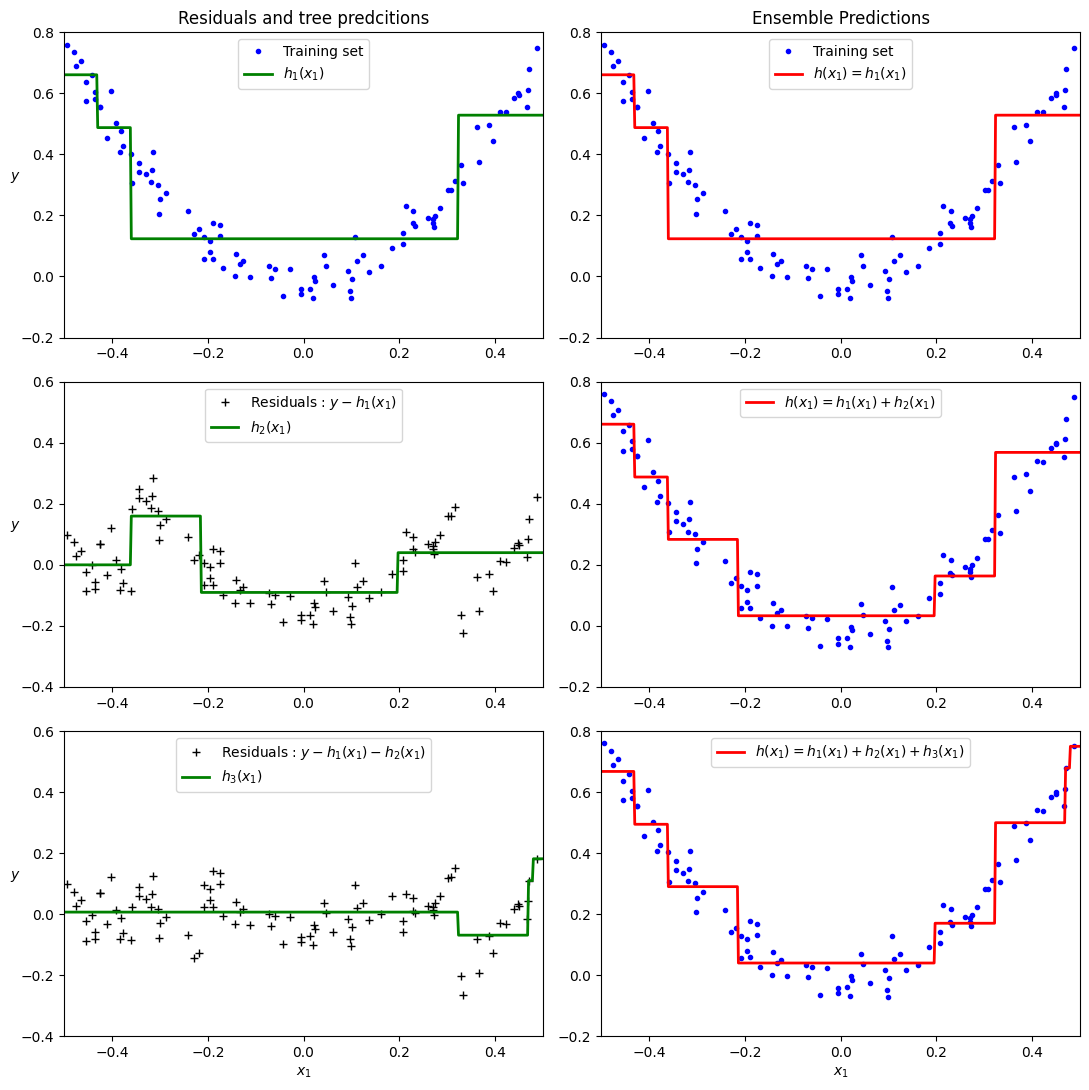

In [7]:
def plot_predictions(regressors, X, y, axes, style, label = None, data_style = "b.", data_label = None):
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1)) for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label = data_label)
    plt.plot(x1, y_pred, style, linewidth = 2, label= label)
    if label or data_label:
        plt.legend(loc = "upper center")
    plt.axis(axes)
    
plt.figure(figsize = (11, 11))

plt.subplot(3, 2, 1)
plot_predictions([tree_reg1], X, y, axes = [-0.5, 0.5, -0.2, 0.8], style = "g-",
                label  = "$h_1(x_1)$", data_label = "Training set")

plt.ylabel("$y$", rotation = 0)
plt.title("Residuals and tree predcitions")

plt.subplot(3, 2, 2)
plot_predictions([tree_reg1], X, y, axes = [-0.5, 0.5, -0.2, 0.8], style = "r-",
                label  = "$h(x_1) = h_1(x_1)$", data_label = "Training set")
plt.title("Ensemble Predictions")

plt.subplot(3, 2, 3)
plot_predictions([tree_reg2], X, y2, axes = [-0.5, 0.5, -0.4, 0.6], style = "g-",
                label  = "$h_2(x_1)$",data_style= "k+", data_label = "Residuals : $y - h_1(x_1)$")
plt.ylabel("$y$", rotation = 0)

plt.subplot(3, 2, 4)
plot_predictions([tree_reg1, tree_reg2], X, y, axes = [-0.5, 0.5, -0.2, 0.8], style = "r-",
                label  = "$h(x_1) = h_1(x_1) + h_2(x_1)$")

plt.subplot(3, 2, 5)
plot_predictions([tree_reg3], X, y3, axes = [-0.5, 0.5, -0.4, 0.6], style = "g-",
                label  = "$h_3(x_1)$", data_style = "k+",
                 data_label = "Residuals : $y - h_1(x_1) - h_2(x_1)$")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation = 0)


plt.subplot(3, 2, 6)
plot_predictions([tree_reg1, tree_reg2, tree_reg3], X, y, 
                 axes = [-0.5, 0.5, -0.2, 0.8], style = "r-",
                label  = "$h(x_1) = h_1(x_1) + h_2(x_1)+ h_3(x_1)$")
plt.xlabel("$x_1$")
save_fig("gradient_boosting_plot")

In [8]:
gbrt = GradientBoostingRegressor(max_depth = 2, n_estimators = 3, learning_rate = 1.0, random_state = 42)
gbrt.fit(X, y)

GradientBoostingRegressor(learning_rate=1.0, max_depth=2, n_estimators=3,
                          random_state=42)

In [9]:
gbrt_best = GradientBoostingRegressor(
    max_depth = 2, learning_rate = 0.05, n_estimators = 500,
    n_iter_no_change = 10, random_state = 42)

gbrt_best.fit(X, y)

GradientBoostingRegressor(learning_rate=0.05, max_depth=2, n_estimators=500,
                          n_iter_no_change=10, random_state=42)

In [10]:
gbrt_best.n_estimators_

92

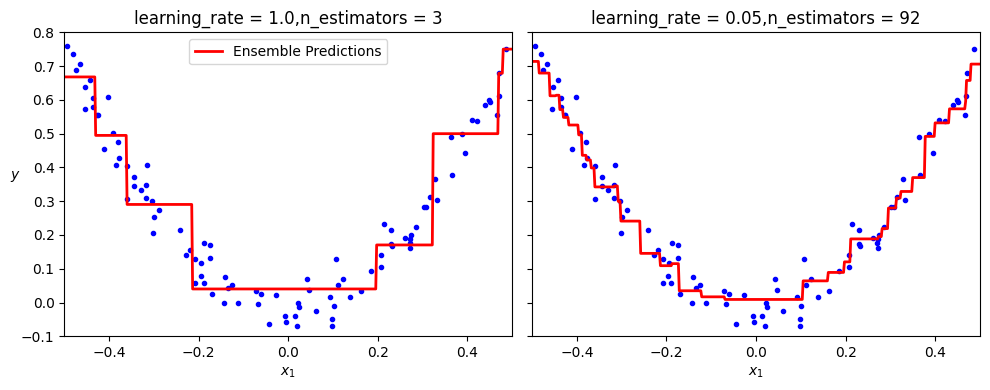

In [11]:
fig, axes = plt.subplots(ncols = 2, figsize = (10, 4), sharey = True)

plt.sca(axes[0])
plot_predictions([gbrt], X, y, axes= [-0.5, 0.5, -0.1, 0.8], style="r-",
                label = "Ensemble Predictions")
plt.title(f"learning_rate = {gbrt.learning_rate},"f"n_estimators = {gbrt.n_estimators_}")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation = 0)

plt.sca(axes[1])
plot_predictions([gbrt_best], X, y, axes= [-0.5, 0.5, -0.1, 0.8], style="r-")
plt.title(f"learning_rate = {gbrt_best.learning_rate},"f"n_estimators = {gbrt_best.n_estimators_}")
plt.xlabel("$x_1$")

save_fig("gbrt_learning_rate_plot")

In [12]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

In [13]:
housing  = load_housing_data()

In [14]:
train_set, test_set= train_test_split(housing, test_size = 0.2, random_state = 42)
housing_labels = train_set["median_house_value"]
housing = train_set.drop("median_house_value", axis = 1)

In [15]:
hgb_reg = make_pipeline(
    make_column_transformer((OrdinalEncoder(), ["ocean_proximity"]),
                            remainder="passthrough"),
    HistGradientBoostingRegressor(categorical_features=[0], random_state=42)
)
hgb_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(),
                                                  ['ocean_proximity'])])),
                ('histgradientboostingregressor',
                 HistGradientBoostingRegressor(categorical_features=[0],
                                               random_state=42))])

In [16]:
hgb_rmse = -cross_val_score(hgb_reg, housing, housing_labels, scoring=  "neg_root_mean_squared_error", cv =10)

pd.Series(hgb_rmse).describe()

count       10.000000
mean     47613.307194
std       1295.422509
min      44963.213061
25%      47001.233485
50%      48000.963564
75%      48488.093243
max      49176.368465
dtype: float64

## Stacking

In [17]:
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [18]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(probability=True, random_state=42))
    ],
    final_estimator=RandomForestClassifier(random_state=43),
    cv=5  # number of cross-validation folds
)
stacking_clf.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('lr', LogisticRegression(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('svc', SVC(probability=True, random_state=42))],
                   final_estimator=RandomForestClassifier(random_state=43))